## **=> Decision Tree**

___

In [22]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report , confusion_matrix , ConfusionMatrixDisplay, accuracy_score

import warnings
warnings.filterwarnings('ignore')

In [23]:
df = pd.read_csv("kyphosis.csv")
df.head()

,Kyphosis,Age,Number,Start
0,absent,71,3,5
1,absent,158,3,14
2,present,128,4,5
3,absent,2,5,1
4,absent,1,4,15


In [24]:
df.shape

(81, 4)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Kyphosis  81 non-null     object
 1   Age       81 non-null     int64 
 2   Number    81 non-null     int64 
 3   Start     81 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 2.7+ KB


In [26]:
df.Kyphosis.value_counts()

Kyphosis
absent     64
present    17
Name: count, dtype: int64

<Axes: xlabel='Kyphosis', ylabel='count'>

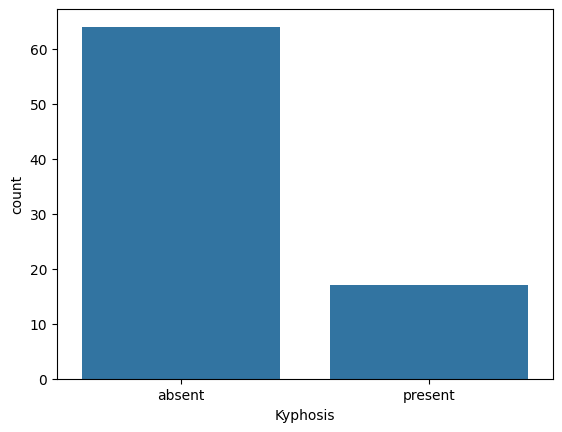

In [27]:
sns.countplot(x="Kyphosis", data = df)

In [28]:
x = df.drop("Kyphosis", axis=1)
y = df.Kyphosis

In [29]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state = 42, test_size = 0.2)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(64, 3)
(64,)
(17, 3)
(17,)


In [30]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)

DecisionTreeClassifier()

<function matplotlib.pyplot.show(close=None, block=None)>

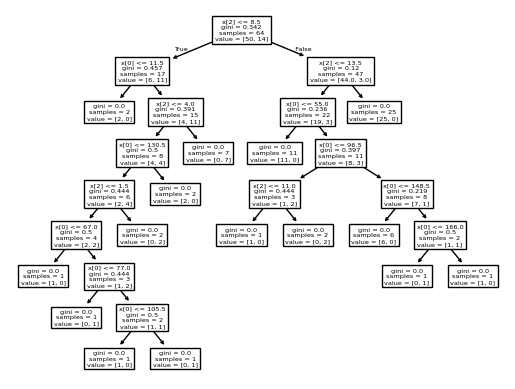

In [31]:
from sklearn import tree
tree.plot_tree(dt)
plt.show

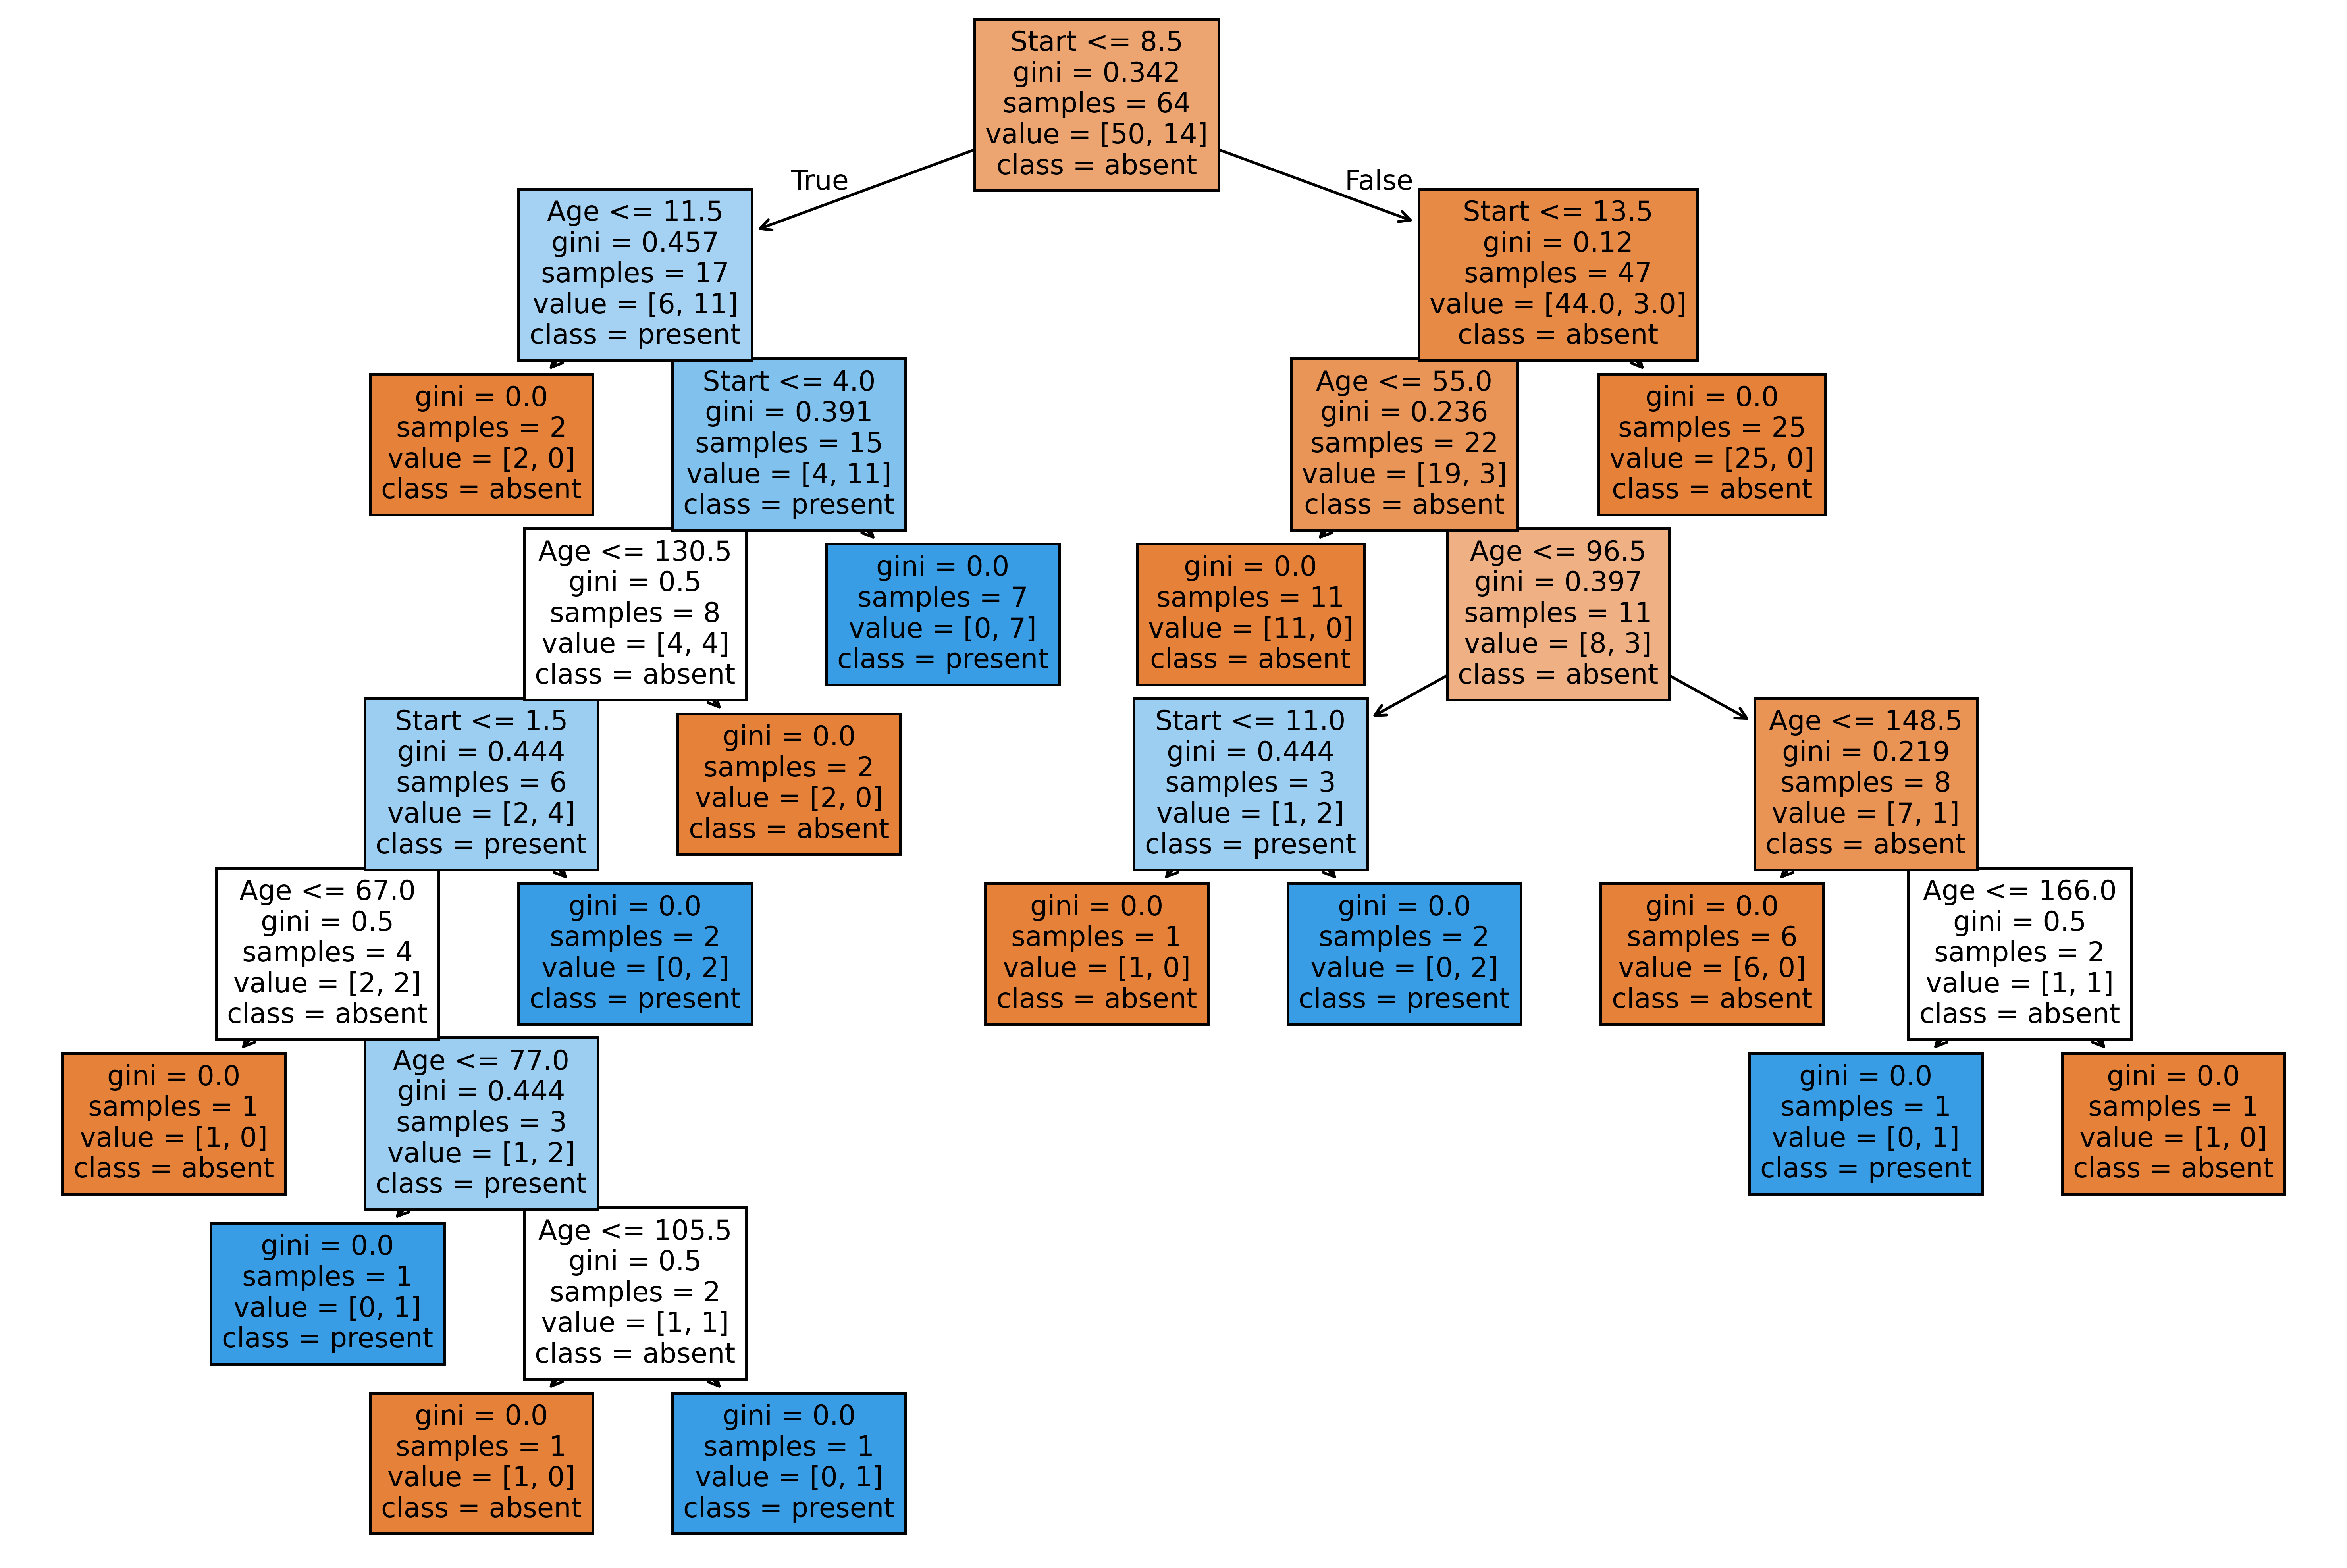

In [42]:
# improve it
fig = plt.figure(figsize=(15,10), dpi=500)
tree.plot_tree(dt, filled=True, feature_names=x.columns, class_names=["absent", "present"])
plt.show()


In [33]:
y_train_pred = dt.predict(x_train)
y_test_pred = dt.predict(x_test)
print(classification_report(y_train, y_train_pred))
print(classification_report(y_test, y_test_pred))
# here we can see that the model is overfitting as the train accuracy is 100% but the test accuracy is 66% only. 
# We will try to improve it by tuning the hyperparameters of the model.

              precision    recall  f1-score   support

      absent       1.00      1.00      1.00        50
     present       1.00      1.00      1.00        14

    accuracy                           1.00        64
   macro avg       1.00      1.00      1.00        64
weighted avg       1.00      1.00      1.00        64

              precision    recall  f1-score   support

      absent       0.85      0.79      0.81        14
     present       0.25      0.33      0.29         3

    accuracy                           0.71        17
   macro avg       0.55      0.56      0.55        17
weighted avg       0.74      0.71      0.72        17



## **=> Random Forest**

___

In [34]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(x_train, y_train)

RandomForestClassifier()

In [35]:
y_train_pred2 = rf.predict(x_train)
y_test_pred2 = rf.predict(x_test)
print(classification_report(y_train, y_train_pred2))
print(classification_report(y_test, y_test_pred2))
# here we can see that the model is still overfitting as the train accuracy is 100%
# but the test accuracy is 82% only, but it is better than the decision tree model.
# We will try to improve it by tuning the hyperparameters of the model 
# like n_estimators cuz it is the number of trees in the forest and by default it is 100

              precision    recall  f1-score   support

      absent       1.00      1.00      1.00        50
     present       1.00      1.00      1.00        14

    accuracy                           1.00        64
   macro avg       1.00      1.00      1.00        64
weighted avg       1.00      1.00      1.00        64

              precision    recall  f1-score   support

      absent       0.82      1.00      0.90        14
     present       0.00      0.00      0.00         3

    accuracy                           0.82        17
   macro avg       0.41      0.50      0.45        17
weighted avg       0.68      0.82      0.74        17



In [ ]:
# here we will set n_estimators to 2 to see the effect of it on the model performance
rf_modified = RandomForestClassifier(n_estimators=2, random_state=42)
rf_modified.fit(x_train, y_train)

RandomForestClassifier(n_estimators=2, random_state=42)

In [37]:
y_train_pred3 = rf_modified.predict(x_train)
y_test_pred3 = rf_modified.predict(x_test)
print(classification_report(y_train, y_train_pred3))
print(classification_report(y_test, y_test_pred3))


              precision    recall  f1-score   support

      absent       0.91      1.00      0.95        50
     present       1.00      0.64      0.78        14

    accuracy                           0.92        64
   macro avg       0.95      0.82      0.87        64
weighted avg       0.93      0.92      0.92        64

              precision    recall  f1-score   support

      absent       0.80      0.86      0.83        14
     present       0.00      0.00      0.00         3

    accuracy                           0.71        17
   macro avg       0.40      0.43      0.41        17
weighted avg       0.66      0.71      0.68        17



In [43]:
#use random over sampling to balance the dataset and then train the model again and see the results.

#import the library for random over sampling
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)
x_train_balanced, y_train_balanced = ros.fit_resample(x_train, y_train)
rf_balanced = RandomForestClassifier(n_estimators=2, random_state=42)   
rf_balanced.fit(x_train_balanced, y_train_balanced)

RandomForestClassifier(n_estimators=2, random_state=42)

In [44]:
y_train_pred4 = rf_balanced.predict(x_train_balanced)
y_test_pred4 = rf_balanced.predict(x_test)  
print(classification_report(y_train_balanced, y_train_pred4))
print(classification_report(y_test, y_test_pred4))

              precision    recall  f1-score   support

      absent       1.00      1.00      1.00        50
     present       1.00      1.00      1.00        50

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

              precision    recall  f1-score   support

      absent       0.81      0.93      0.87        14
     present       0.00      0.00      0.00         3

    accuracy                           0.76        17
   macro avg       0.41      0.46      0.43        17
weighted avg       0.67      0.76      0.71        17

